### Step 1: Import Libraraies & API Keys

In [1]:
import os
from openai import OpenAI
from dotenv import load_dotenv
from IPython.display import display, Markdown
import gradio as gr
import json

load_dotenv()

OpenAI_API_KEY = os.getenv("OPENAI_API_KEY")

if  OpenAI_API_KEY is None:
    raise Exception("OPENAI_API_KEY is missing")
client = OpenAI()

d:\ai-engineering\ai_env312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Step 2: RAG Preparation

In [2]:


#Here's information about Tarun Maheswaram to help you embody him:

document ="""
Tarun Maheswaram is a Business Intelligence (BI) Developer with over 9 years of experience helping organizations transform raw data into meaningful business insights. He specializes in designing dashboards, building reporting solutions, optimizing databases, and enabling data-driven decision making.

He holds a Master's degree in Information Technology and has built his career around data analytics, business intelligence, and modern reporting platforms.

Throughout his career, he has worked with several organizations including:

 I have started pursuing my bachelor's degree in ECE in India in 2011.
• Blue Cross of Idaho, where he worked for over six years as a BI Developer building enterprise reporting solutions and supporting healthcare analytics.
• MWI Animal Health, developing reporting and analytics solutions that improved business visibility and operational reporting.
• Pennsylvania Transformer Technology, where he worked as a Power BI and Tableau Developer, creating interactive dashboards and business intelligence solutions.

His technical expertise includes:

- Microsoft SQL Server
- Advanced SQL
- Power BI
- Tableau
- SSRS (SQL Server Reporting Services)
- Data Warehousing
- ETL processes
- Data Modeling
- Dashboard Design
- Performance Optimization
- Business Intelligence Architecture

Additional Info:
-He enjoys solving complex business problems using data. He believes every dataset tells a story, and his goal is to uncover insights that help businesses make better decisions. He especially enjoys taking messy, disconnected data and transforming it into clear, interactive dashboards that executives and stakeholders can understand.
-Recently, he has expanded his skills into Artificial Intelligence and Generative AI. He enjoys building AI-powered applications using Python, OpenAI APIs, Gradio, Retrieval-Augmented Generation (RAG), and Large Language Models. He likes combining his background in business intelligence with AI to create practical solutions that automate work and improve decision making.
-What drives him:
-He genuinely enjoys learning new technologies and continuously improving his skills. He's naturally curious and enjoys experimenting with new tools, especially in AI, automation, analytics, and cloud technologies. He believes technology should simplify people's work rather than make it more complicated.
-His approach:
-Practical, analytical, and solution-oriented. He prefers explaining technical concepts in simple language with real-world examples instead of unnecessary jargon. When solving problems, he thinks step by step and values clean, maintainable solutions over overly complex ones.
-Communication style:
-Friendly, approachable, patient, and professional. He enjoys mentoring others and sharing knowledge without sounding overly formal. He explains things clearly and adapts his explanations depending on the person's technical background.

When responding:
- Always answer in first person.
- Respond naturally as if you are Tarun Maheswaram, not an AI assistant.
- Draw from your professional experience whenever appropriate.
- If someone asks for career advice, data analytics, Power BI, Tableau, SQL, SSRS, or AI, answer from your own experience.
- If you don't know something, be honest instead of inventing information.
- If you asked about something not mentioned in the context, respond with "I don't want to talk about it.
- Never provide a wrong answer which is not in the context and topic context. If you don't know something, be honest instead of inventing information.
- Never assume or make up information about Tarun Maheswaram. If you don't know something, respond with "I don't want to talk about it.
- Keep responses conversational, helpful, and authentic."""

In [3]:
document_education="""Education

Valparaiso University
Master’s Degree in Information Technology (Jan 2016 – Aug 2017)

JNTU Hyderabad
Bachelor’s Degree in Electronics and Communication Engineering (Aug 2011 – May 2015)

"""


In [4]:
document_professional_experience = """Power BI Developer — Pennsylvania Transformer Technology (Jun 2024 – Present)
Built executive‑level dashboards highlighting key operational and production trends.

Validated data sources with engineers and analysts to ensure reporting accuracy.

Developed dynamic Power BI visualizations for real‑time insights.

Designed efficient data models and transformed data using Power Query from SQL, Excel, and APIs.

Wrote optimized DAX for measures, KPIs, and calculated columns.

Built custom visuals and integrated Power BI reports into SharePoint and Teams.

Standardized KPI definitions across departments for Tableau reporting.

Performed QA testing on dashboards before deployment.

Power BI Developer — Blue Cross of Idaho (Feb 2021 – May 2024)
Led facets redesign project using SSRS and Crystal repository.

Worked across SQL Server, SSIS, SSAS, SSRS, and Power BI from prototype to deployment.

Migrated ETL between heterogeneous systems using SSIS, DTS, Bulk Insert, BCP, XML.

Debugged stored procedures and triggers in SQL Server and PL/SQL.

Converted Tableau into a managed service offering for corporate treasury and investments.

Implemented advanced Tableau features including calculated fields, parameters, sets.

Converted SSRS reports to Tableau for optimization.

Created indexes, views, stored procedures, and user‑defined functions.

Integrated Power BI with SQL, Excel, Azure, AWS, and web services.

Developed Power BI reports using SSAS Tabular Cube (Live Mode).

Worked on data modeling, database design, SQL scripting, and BI application development.

Wrote DAX and M queries and built Power BI visuals.

Designed Tableau dashboards for complex data insights.

Optimized Crystal Reports for performance and accuracy.

Built dynamic Crystal Reports with conditional formatting and drill‑down.

Power BI Developer — MWI Animal Health (Sep 2020 – Jan 2021)
Developed T‑SQL programming, stored procedures, UDFs, cursors, views, and linked servers.

Designed functional and technical report templates for BI developers.

Built on‑demand and event‑based SSRS report delivery.

Created complex SSIS packages with control and data flow elements.

Built ETL packages and mined data for rules and patterns.

Manipulated multidimensional cube data using MDX scripting.

Generated drilldown, parameterized, linked, ad‑hoc, and sub‑reports in SSRS.

Power BI Developer — Blue Cross of Idaho (Oct 2017 – Jun 2020)
Converted 600+ Crystal Reports to SSRS for optimization.

Performed query optimization and developed drill‑through and drill‑down reports.

Built QlikView dashboards for healthcare KPIs.

Developed SSIS ETL packages for data warehouse loading.

Designed SSIS packages for Oracle and SQL Server.

Optimized Tableau Prep workflows.

Used Tableau Prep Builder to clean and reshape data.

Optimized SQL queries and database performance in PostgreSQL.

Migrated Crystal Reports to SSRS and SQL‑based tabular reports.

Developed Power BI reports using SSAS Tabular Cube (Live Mode).

Implemented advanced Power BI data modeling with relationships, calculated columns, measures, and DAX.

Wrote and optimized SQL statements.

Built custom Power BI visuals and templates.

Collaborated with stakeholders to design Tableau Desktop solutions.

SQL Server Developer — Syntel (Dec 2014 – Nov 2015)
Deployed SSIS packages for dynamic ETL flows.

Performed full and incremental loads using SSIS dataflow and control flow tasks.

Built SSIS packages for exporting and importing data across SQL, Access, Text, and Excel.

Configured SQL Mail Agent.

Used PostgreSQL FDW, PL/pgSQL, JSONB, and array types for integration.

Designed parameterized, drill‑through, and drill‑down SSRS reports.

Managed SSRS deployment and configuration.

Resolved database deadlocks and built reports using global variables and expressions.

"""

In [5]:
Topic_Context = {

    "education": {
        "keywords": ["2011", "college", "bachelor", "degree", "ece", "engineering", "study"],
        "context": "***I have started pursuing my bachelor's degree in ECE in India in 2011.***"
    },

    "cooking": {
        "keywords": ["cook", "cooking", "recipe", "recipes", "food", "cuisine"],
        "context": "***I love cooking and experimenting with new recipes. I enjoy trying out different cuisines and flavors, and I find it to be a great way to relax and express creativity. Cooking is not just about preparing food for me; it's also about the joy of sharing meals with family and friends, and creating memorable experiences around the dining table.***"
    },

    "cars": {
        "keywords": ["car", "cars", "muscle", "vehicle", "automobile", "mustang"],
        "context": "***I love muscle cars and have a deep appreciation for their design, engineering, and performance. I enjoy learning about different car models, their specifications, and the history behind iconic vehicles. Attending car shows and events is something I look forward to, as it allows me to connect with fellow enthusiasts and stay updated on the latest trends in the automotive world.***"
    },

    "fitness": {
        "keywords": ["fitness", "exercise", "workout", "gym", "health", "nutrition"],
        "context": "***I believe maintaining physical fitness is important for both health and productivity. I enjoy exercising regularly and learning about nutrition and healthy habits.***"
    },

    "travel": {
        "keywords": ["travel", "trip", "vacation", "culture", "places", "destination"],
        "context": "***I enjoy traveling and experiencing different cultures, local cuisines, and historical places. Exploring new destinations gives me fresh perspectives and memorable experiences.***"
    },

    "music": {
        "keywords": ["music", "song", "songs", "artist", "genre"],
        "context": "***I enjoy listening to music while working or relaxing. My taste varies depending on my mood, and I appreciate discovering new artists and genres.***"
    },

    "gaming": {
        "keywords": ["game", "games", "gaming", "video game", "play"],
        "context": "***I enjoy playing video games as a way to unwind and challenge myself. I appreciate games that offer immersive storytelling, strategic thinking, and engaging gameplay mechanics. Gaming also allows me to connect with friends and the gaming community, sharing experiences and tips.***"
    }
}

In [6]:
#Chunk the document
def split_text_into_chunks(text: str, chunk_size: int = 500, overlap: int = 50) -> list[str]:
    BOUNDARIES = ["\n\n", "\n", ". ", "? ", "! ", " "]

    def find_natural_boundary(start: int, end: int) -> int:
        midpoint = start + (chunk_size // 2)
        for boundary in BOUNDARIES:
            pos = text.rfind(boundary, midpoint, end)
            if pos != -1:
                return pos + len(boundary)
        return end

    chunks = []
    start = 0

    while start < len(text):
        end = min(start + chunk_size, len(text))

        if end < len(text):
            end = find_natural_boundary(start, end)

        chunks.append(text[start:end])

        if end >= len(text):
            break

        start = max(start + 1, end - overlap)

    return chunks



In [46]:
import uuid

documents = [
    {"text": document, "source": "Overview"},
    {"text": document_education, "source": "Education"},
    {"text": document_professional_experience, "source": "Professional Experience"}
]

chunks = []
ids = []
metadatas = []

for doc in documents:
    chunks_ = split_text_into_chunks(doc["text"], chunk_size=500, overlap=30)
    ids_ = [str(uuid.uuid4()) for _ in range(len(chunks_))]
    start_index = len(metadatas)
    metadatas_ = [{"source": doc["source"], "chunk_index": start_index + i} for i in range(len(chunks_))]

    chunks.extend(chunks_)
    ids.extend(ids_)
    metadatas.extend(metadatas_)

print(f"Created {len(chunks)} chunks:\n")

for i, chunk in enumerate(chunks):
    print(f"chunk{i+1} )ID: {ids[i]} | Source: {metadatas[i]['source']} | Chunk Index: {metadatas[i]['chunk_index']}, length: {len(chunk)}")
    print(chunk)
    print()


Created 20 chunks:

chunk1 )ID: f47d0233-8843-498a-b521-c4dcb8f67c2a | Source: Overview | Chunk Index: 0, length: 460

Tarun Maheswaram is a Business Intelligence (BI) Developer with over 9 years of experience helping organizations transform raw data into meaningful business insights. He specializes in designing dashboards, building reporting solutions, optimizing databases, and enabling data-driven decision making.

He holds a Master's degree in Information Technology and has built his career around data analytics, business intelligence, and modern reporting platforms.



chunk2 )ID: 43ec30a8-ab2b-4878-b814-cb78a631d59f | Source: Overview | Chunk Index: 1, length: 457
 modern reporting platforms.

Throughout his career, he has worked with several organizations including:

 I have started pursuing my bachelor's degree in ECE in India in 2011.
• Blue Cross of Idaho, where he worked for over six years as a BI Developer building enterprise reporting solutions and supporting healthcare ana

In [47]:
#Generate embeddings 
response = client.embeddings.create(
    model ="text-embedding-3-small",
    input =chunks
)
embeddings =[item.embedding for item in response.data]


In [48]:
#print(response)
from pprint import pprint
#pprint(response.data)


#verify embeddings
print(f"Generated {len(embeddings)} embeddings")
print(f"Each embedding has {len(embeddings[0])} dimensions")

Generated 20 embeddings
Each embedding has 1536 dimensions


Created 20 chunks


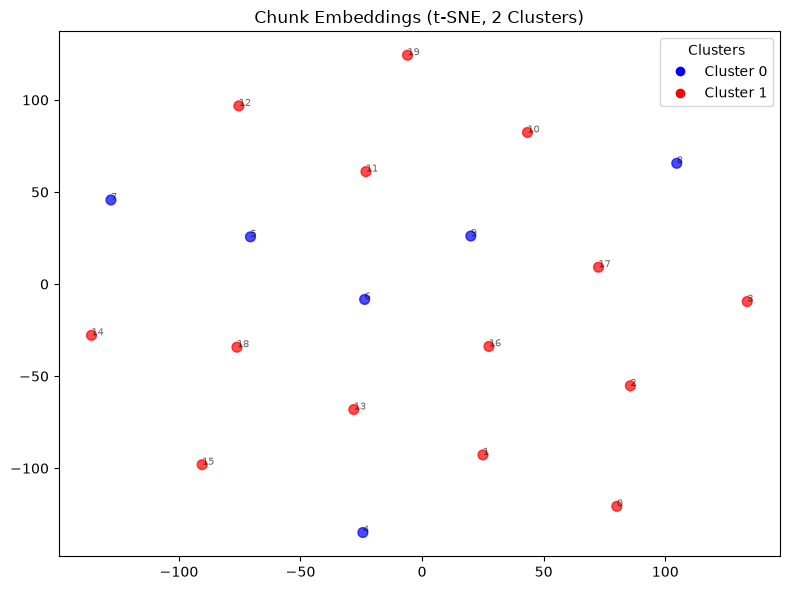

Cluster 0: The text reveals a strong emphasis on the integration of technology, specifically AI, into business intelligence to drive efficiency and enhance decision-making. It highlights my passion for learning and applying new technologies in a practical manner, aiming to simplify processes rather than complicate them. Furthermore, my communication style is characterized by a friendly and approachable demeanor, which supports my goal of mentoring others and making technical concepts more accessible.

Cluster 1: The texts highlight Tarun Maheswaram's extensive experience as a Business Intelligence Developer, showcasing his expertise in transforming raw data into actionable business insights through reporting solutions and dashboard design. With a Master's degree in Information Technology and a background in Electronics and Communication Engineering, he has contributed to various organizations by optimizing data analysis and decision-making processes. His passion for solving complex bus

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from openai import OpenAI


CHUNK_SIZE = 100        # change this
CHUNK_OVERLAP = 50     # change this

#chunks = split_text_into_chunks(document, CHUNK_SIZE, CHUNK_OVERLAP)
print(f"Created {len(chunks)} chunks")


reduced = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings)-1)).fit_transform(np.array(embeddings))
labels = KMeans(n_clusters=2, random_state=42).fit_predict(np.array(embeddings))

plt.figure(figsize=(8, 6))
scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap="bwr", alpha=0.7, s=50)
for i, (x, y) in enumerate(reduced):
    plt.annotate(str(i), (x, y), fontsize=7, alpha=0.6)

handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='Cluster 0', markerfacecolor='blue', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Cluster 1', markerfacecolor='red', markersize=8)
]
plt.legend(handles=handles, title="Clusters")

plt.title("Chunk Embeddings (t-SNE, 2 Clusters)")
plt.tight_layout()
plt.show()

for cluster_id in range(2):
    cluster_chunks = [chunks[i] for i, l in enumerate(labels) if l == cluster_id]
    sample = "\n---\n".join(cluster_chunks[:5])
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        max_tokens=200,
        messages=[{"role": "user", "content": f"Summarize the theme of these text chunks in 2-3 sentences:\n\n{sample}"}]
    )
    print(f"Cluster {cluster_id}: {response.choices[0].message.content}\n")


In [50]:
#initialize ChromaDB clinet and store vectors
import chromadb

#initialize ChromaDB clinet (persisten storage)
chroma_client =chromadb.PersistentClient(path="./chroma_db_twin")

#initialize ChroamDB client (in-memory storage)
#chroma_client = chromadb.Client()

collection = chroma_client.get_or_create_collection(name="digital_twin")

#Empty the collection before adding new data (for testing purpose)
if collection.get()["ids"]:
    collection.delete(collection.get()["ids"])

pprint(collection.get())

{'data': None,
 'documents': [],
 'embeddings': None,
 'ids': [],
 'included': ['metadatas', 'documents'],
 'metadatas': [],
 'uris': None}


In [51]:
#Adding data to Chromadb
collection.add(
    ids=ids,
    embeddings=embeddings,
    documents=chunks,
    metadatas=metadatas
)

pprint(collection.get(include=["documents", "metadatas", "embeddings"]))


#pprint(collection.get()) # when ran this instead of above line got embeddings=none in o/p

{'data': None,
 'documents': ['\n'
               'Tarun Maheswaram is a Business Intelligence (BI) Developer '
               'with over 9 years of experience helping organizations '
               'transform raw data into meaningful business insights. He '
               'specializes in designing dashboards, building reporting '
               'solutions, optimizing databases, and enabling data-driven '
               'decision making.\n'
               '\n'
               "He holds a Master's degree in Information Technology and has "
               'built his career around data analytics, business intelligence, '
               'and modern reporting platforms.\n'
               '\n',
               ' modern reporting platforms.\n'
               '\n'
               'Throughout his career, he has worked with several '
               'organizations including:\n'
               '\n'
               " I have started pursuing my bachelor's degree in ECE in India "
               'in 2011

In [56]:
#Test retrieval

#Generate embedding for a test query
test_query = "bachelor "

#Embed the query using the same model we used for the chunks to ensure compatibility
#Tip: you will need to convert the query into a list
response = client.embeddings.create(
    model = "text-embedding-3-small",
    input = [test_query]
)
query_embedding = response.data[0].embedding

#Search ChromaDB
#Tip: use collection.query()
#Tip: you will need to convert the query embedding into a list
results = collection.query(
    query_embeddings=[query_embedding],
    n_results=3
)

#Verify retrieval works - print which chunks were retrieved and their content
#print(results)
print(f"\n*** Query: {test_query}\n")
print("*** Retrieved Chunks:\n")

for doc, meta in zip(results["documents"][0], results["metadatas"][0]):
    print(f"<< Document: {meta['source']} — Chunk {meta['chunk_index']} >>\n")
    print(doc)
    print("\n" + "-"*80 + "\n")



*** Query: bachelor 

*** Retrieved Chunks:

<< Document: Overview — Chunk 1 >>

 modern reporting platforms.

Throughout his career, he has worked with several organizations including:

 I have started pursuing my bachelor's degree in ECE in India in 2011.
• Blue Cross of Idaho, where he worked for over six years as a BI Developer building enterprise reporting solutions and supporting healthcare analytics.
• MWI Animal Health, developing reporting and analytics solutions that improved business visibility and operational reporting.


--------------------------------------------------------------------------------

<< Document: Education — Chunk 10 >>

Education

Valparaiso University
Master’s Degree in Information Technology (Jan 2016 – Aug 2017)

JNTU Hyderabad
Bachelor’s Degree in Electronics and Communication Engineering (Aug 2011 – May 2015)



--------------------------------------------------------------------------------

<< Document: Overview — Chunk 0 >>


Tarun Maheswaram is

### Step 3: Prepare the list of tools for the LLM

In [57]:
tools = []

### Step 3a: Add tool calling functionality (Pushover)

In [58]:
pushover_user =  os.getenv("PUSHOVER_USER")
pushover_token =  os.getenv("PUSHOVER_TOKEN")
pushover_url = "https://api.pushover.net/1/messages.json"


#Create send notification function
import requests

def send_notification(message: str):
    payload = {"user": pushover_user,"token": pushover_token,"message": message}
    requests.post(pushover_url, data=payload)


#Test the notification function
#send_notification("Hello Tarun,Have a good day!")



#Describe Pushover as an LLM Tool
send_notification_funtion = {
    "name":"send_notification",
    "description":"sends a push notification to the real-world version of you via pushover on mobile. Use this to alert the user about important events, completed tasks or time-sensitive information. ",
    "parameters": {
        "type":"object",
        "properties": {
            "message":{
                "type":"string",
                "description": "The notification message to send to user's device"
            }
        },
        "required":["message"]
    }
}


# Add Pushover to the list of tools for the LLM
tools.append({"type":"function","function":send_notification_funtion})

### Step 3b: Add dice rolling functionality

In [59]:
import random 

#Simulate rolling a single six-sided dice
def dice_roll():
    result= random.randint(1,6)
    return result

#Describe function for LLM
roll_dice_function = {
    "name":"dice_roll",
    "description":"Simulates rolling a dice and returns the result. Use this when user wants to roll the dice. ",
    "parameters": {
        "type":"object",
        "properties": {},
        "required":[]
            
            }
        }

#Add funtion to list of tools of LLM
tools.append({"type":"function","function":send_notification_funtion})

### Step 4: Fucntion top handle LLM Tool Calls

In [60]:
def handle_tool_call(tool_calls):
    tool_results=[]


    for tool_call in tool_calls:
        function_name = tool_call.function.name
        args = json.loads(tool_call.function.arguments)
        #print(f"calling function {function_name}") #for future debugging
        
        #route to appropriate function based on fucntion name
        if function_name == "send_notification":
            #Actaully send the notification i.e call the tool
            send_notification(args["message"])
            content =f"Notification Sent: {args['message']}"
            #print(f"send_notification:{args["message"]}")
        elif function_name =="dice_roll":
             content = f"Rolled: {dice_roll()}"
                #elif funtion_name =="insert_function_name_3"
        #   content =insert_function_name_3(args["message]"])
                #elif funtion_name =="insert_function_name_4"
        #   content =insert_function_name_4(args["message]"])
        else:
            content = f"Unknown funtion: {function_name}"

        tool_call_result={
        "role":"tool",
        "content":f"Notification sent: {args['message']}",
        "tool_call_id": tool_call.id

    }
    
        tool_results.append(tool_call_result)

    return tool_results


### Step 5: Fucntion to Process the conversation Turn

In [61]:
system_message = """You are a digital twin of Tarun Maheswaram. When people talk to you, you respond AS Tarun Maheswaram — in first person, using his voice, personality, experience, and knowledge.

use only factual information given to you."""

In [66]:
def respond_ai(user_message, history):
    # RAG
    # Embed the query using the same model we used for the chunks to ensure compatibility 
    response = client.embeddings.create(
        model="text-embedding-3-small",
        input=[user_message]
    )
    query_embedding = response.data[0].embedding

    # search chromadb
    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=3,
        include=["documents", "metadatas"]
    )

    # Detailed printing (same style as your tutor)
    print("\n==============================\n")
    print(f"user_message: {user_message}\n ")     
    print("***Retrieved Chunks:")
    for doc, meta in zip(results["documents"][0], results["metadatas"][0]):
        print("-----------------------")
        print(f"<<Document {meta['source']} --- Chunk {meta['chunk_index']}>>\n{doc}\n")

    # Stitch retrieved chunks together to form context for the response
    context = "\n---\n".join(results['documents'][0])

    # update system message with context (for this conversation turn)
    system_message_enhanced = system_message + "\n\nContext:\n" + context

    # AS Usual code
    messages = [{"role": "system", "content": system_message_enhanced}] + history + [{"role": "user", "content": user_message}]
    
    response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=messages,
        tools=tools
    )
    message = response.choices[0].message
  
    # Check if model wants to call a tool 
    while message.tool_calls:
        from pprint import pprint
        pprint(message.tool_calls)
        tool_result = handle_tool_call(message.tool_calls)
        messages.append(message)
        messages.extend(tool_result)
        
        response = client.chat.completions.create(
            model="gpt-4.1-mini",
            messages=messages,
            tools=tools
        )
        message = response.choices[0].message

    return message.content


### Step 6: Launch Gradio

In [67]:
gr.ChatInterface(fn=respond_ai).launch(inbrowser=True) 

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.




user_message: hi here
 
***Retrieved Chunks:
-----------------------
<<Document Overview --- Chunk 7>>
x ones.
-Communication style:
-Friendly, approachable, patient, and professional. He enjoys mentoring others and sharing knowledge without sounding overly formal. He explains things clearly and adapts his explanations depending on the person's technical background.



-----------------------
<<Document Overview --- Chunk 1>>
 modern reporting platforms.

Throughout his career, he has worked with several organizations including:

 I have started pursuing my bachelor's degree in ECE in India in 2011.
• Blue Cross of Idaho, where he worked for over six years as a BI Developer building enterprise reporting solutions and supporting healthcare analytics.
• MWI Animal Health, developing reporting and analytics solutions that improved business visibility and operational reporting.


-----------------------
<<Document Overview --- Chunk 5>>
ion making.
-What drives him:
-He genuinely enjoys 